In [1]:
import pennylane as qml
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader

# various qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector, SparsePauliOp, random_clifford

# qiskit ml imports
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

from scipy.stats import unitary_group

import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
from tqdm import trange

from main import QuantumNeuralNetwork

     ┌──────────┐┌──────────┐┌──────────┐          ┌───┐ ░  ┌──────────┐»
q_0: ┤ Rx(θ[0]) ├┤ Ry(θ[1]) ├┤ Rz(θ[2]) ├──■───────┤ X ├─░──┤ Rx(θ[9]) ├»
     ├──────────┤├──────────┤├──────────┤┌─┴─┐     └─┬─┘ ░ ┌┴──────────┤»
q_1: ┤ Rx(θ[3]) ├┤ Ry(θ[4]) ├┤ Rz(θ[5]) ├┤ X ├──■────┼───░─┤ Rx(θ[12]) ├»
     ├──────────┤├──────────┤├──────────┤└───┘┌─┴─┐  │   ░ ├───────────┤»
q_2: ┤ Rx(θ[6]) ├┤ Ry(θ[7]) ├┤ Rz(θ[8]) ├─────┤ X ├──■───░─┤ Rx(θ[15]) ├»
     └──────────┘└──────────┘└──────────┘     └───┘      ░ └───────────┘»
«     ┌───────────┐┌───────────┐          ┌───┐ ░ 
«q_0: ┤ Ry(θ[10]) ├┤ Rz(θ[11]) ├──■───────┤ X ├─░─
«     ├───────────┤├───────────┤┌─┴─┐     └─┬─┘ ░ 
«q_1: ┤ Ry(θ[13]) ├┤ Rz(θ[14]) ├┤ X ├──■────┼───░─
«     ├───────────┤├───────────┤└───┘┌─┴─┐  │   ░ 
«q_2: ┤ Ry(θ[16]) ├┤ Rz(θ[17]) ├─────┤ X ├──■───░─
«     └───────────┘└───────────┘     └───┘      ░ 

QuantumNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
  

Added random LU equivalent biseparable-1 states to training data:   0%|          | 0/350 [00:00<?, ?it/s]

Added random LU equivalent biseparable-1 states to training data: 100%|██████████| 350/350 [00:00<00:00, 605.93it/s]
Added random LU equivalent separable states to training data    : 100%|██████████| 70/70 [00:00<00:00, 977.45it/s]
Added random LU equivalent linear states to training data       : 100%|██████████| 70/70 [00:00<00:00, 708.63it/s]
Added random LU equivalent biseparable-2 states to training data: 100%|██████████| 70/70 [00:00<00:00, 649.51it/s]
Added random LU equivalent biseparable-3 states to training data: 100%|██████████| 70/70 [00:00<00:00, 768.96it/s]
Added random LU equivalent star states to training data         : 100%|██████████| 70/70 [00:00<00:00, 931.42it/s]



[2/3] Generating test data...


Added random LU equivalent biseparable-1 states to testing data: 100%|██████████| 150/150 [00:00<00:00, 658.88it/s]
Added random LU equivalent separable states to testing data    : 100%|██████████| 30/30 [00:00<00:00, 689.74it/s]
Added random LU equivalent linear states to testing data       : 100%|██████████| 30/30 [00:00<00:00, 792.15it/s]
Added random LU equivalent biseparable-2 states to testing data: 100%|██████████| 30/30 [00:00<00:00, 954.44it/s]
Added random LU equivalent biseparable-3 states to testing data: 100%|██████████| 30/30 [00:00<00:00, 954.01it/s]
Added random LU equivalent star states to testing data         : 100%|██████████| 30/30 [00:00<00:00, 706.60it/s]



Dataset ready:
Training: 700 samples
Test: 300 samples
Class balance: 350 target / 350 other
Epoch [  1/50 ] Loss: 0.9849 | Train Acc:  56.57% | Test Acc:  84.33%
Epoch [  5/50 ] Loss: 0.5786 | Train Acc:  80.86% | Test Acc:  84.67%
Epoch [ 10/50 ] Loss: 0.5632 | Train Acc:  81.29% | Test Acc:  84.67%
Epoch [ 15/50 ] Loss: 0.5586 | Train Acc:  81.57% | Test Acc:  85.33%
Epoch [ 20/50 ] Loss: 0.5012 | Train Acc:  83.00% | Test Acc:  90.00%
Epoch [ 25/50 ] Loss: 0.3857 | Train Acc:  87.14% | Test Acc:  92.00%
Epoch [ 30/50 ] Loss: 0.3516 | Train Acc:  87.71% | Test Acc:  92.33%
Epoch [ 35/50 ] Loss: 0.3285 | Train Acc:  88.86% | Test Acc:  92.33%
Epoch [ 40/50 ] Loss: 0.3282 | Train Acc:  88.71% | Test Acc:  91.33%
Epoch [ 45/50 ] Loss: 0.3285 | Train Acc:  88.57% | Test Acc:  92.33%
Epoch [ 50/50 ] Loss: 0.3169 | Train Acc:  88.71% | Test Acc:  91.33%

Final Training Accuracy: 88.71%
Final Test Accuracy:     91.33%


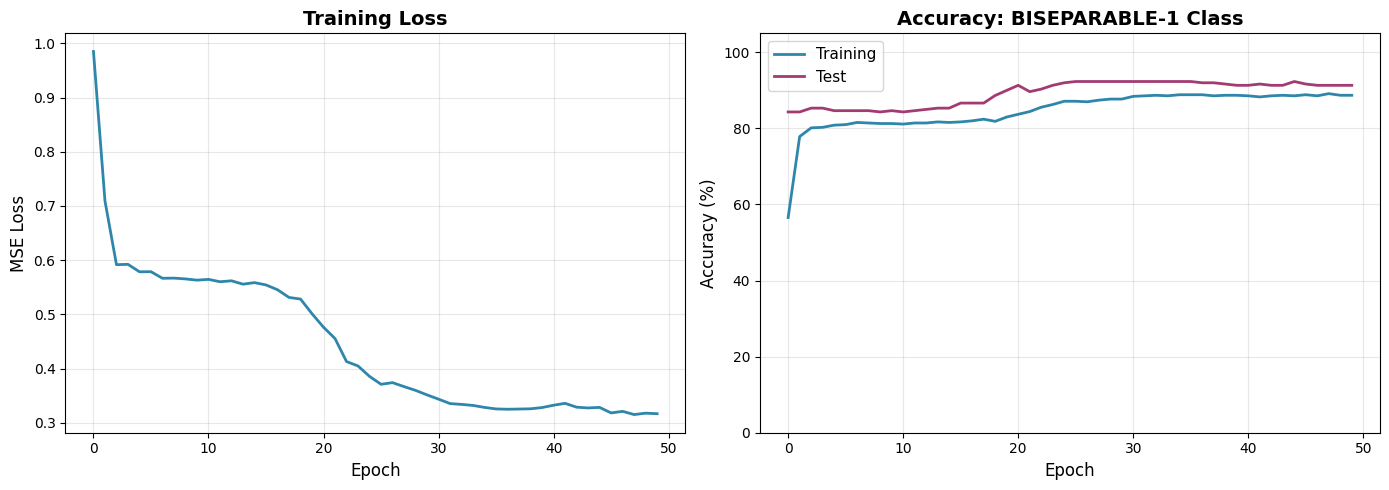

In [4]:
qnn = QuantumNeuralNetwork(n_layers=2, hidden_dims=[16, 8, 4, 2])

classes = {
    'separable': [],
    'linear': [(0, 1), (1, 2)],
    'biseparable-1': [(0, 1)],
    'biseparable-2': [(1, 2)],
    'biseparable-3': [(0, 2)],
    'star': [(0, 1), (0, 2), (1, 2)]
}

print(qnn.vqc)
print(qnn)

metrics = qnn.train_for_class(
    target_class='biseparable-1',
    entanglement_classes=classes,
    n_train=700,
    n_test=300,
    use_LC=False,  # LC orbit classification
    epochs=50,
    learning_rate=0.01
)

     ┌──────────┐┌──────────┐┌──────────┐          ┌───┐ ░  ┌──────────┐»
q_0: ┤ Rx(θ[0]) ├┤ Ry(θ[1]) ├┤ Rz(θ[2]) ├──■───────┤ X ├─░──┤ Rx(θ[9]) ├»
     ├──────────┤├──────────┤├──────────┤┌─┴─┐     └─┬─┘ ░ ┌┴──────────┤»
q_1: ┤ Rx(θ[3]) ├┤ Ry(θ[4]) ├┤ Rz(θ[5]) ├┤ X ├──■────┼───░─┤ Rx(θ[12]) ├»
     ├──────────┤├──────────┤├──────────┤└───┘┌─┴─┐  │   ░ ├───────────┤»
q_2: ┤ Rx(θ[6]) ├┤ Ry(θ[7]) ├┤ Rz(θ[8]) ├─────┤ X ├──■───░─┤ Rx(θ[15]) ├»
     └──────────┘└──────────┘└──────────┘     └───┘      ░ └───────────┘»
«     ┌───────────┐┌───────────┐          ┌───┐ ░ 
«q_0: ┤ Ry(θ[10]) ├┤ Rz(θ[11]) ├──■───────┤ X ├─░─
«     ├───────────┤├───────────┤┌─┴─┐     └─┬─┘ ░ 
«q_1: ┤ Ry(θ[13]) ├┤ Rz(θ[14]) ├┤ X ├──■────┼───░─
«     ├───────────┤├───────────┤└───┘┌─┴─┐  │   ░ 
«q_2: ┤ Ry(θ[16]) ├┤ Rz(θ[17]) ├─────┤ X ├──■───░─
«     └───────────┘└───────────┘     └───┘      ░ 

QuantumNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
  

Added random LU equivalent biseparable-1 states to training data: 100%|██████████| 450/450 [00:00<00:00, 502.82it/s]
Added random LU equivalent biseparable-2 states to training data: 100%|██████████| 225/225 [00:00<00:00, 873.39it/s]
Added random LU equivalent biseparable-3 states to training data: 100%|██████████| 225/225 [00:00<00:00, 962.04it/s] 



[2/3] Generating test data...


Added random LU equivalent biseparable-1 states to testing data: 100%|██████████| 50/50 [00:00<00:00, 625.48it/s]
Added random LU equivalent biseparable-2 states to testing data: 100%|██████████| 25/25 [00:00<00:00, 800.56it/s]
Added random LU equivalent biseparable-3 states to testing data: 100%|██████████| 25/25 [00:00<00:00, 709.79it/s]



Dataset ready:
Training: 900 samples
Test: 100 samples
Class balance: 450 target / 450 other
Epoch [  1/50 ] Loss: 1.0030 | Train Acc:  49.11% | Test Acc:  50.00%
Epoch [  5/50 ] Loss: 0.2838 | Train Acc:  90.78% | Test Acc:  95.00%
Epoch [ 10/50 ] Loss: 0.2689 | Train Acc:  91.11% | Test Acc:  95.00%
Epoch [ 15/50 ] Loss: 0.2660 | Train Acc:  91.22% | Test Acc:  96.00%
Epoch [ 20/50 ] Loss: 0.2614 | Train Acc:  91.11% | Test Acc:  96.00%
Epoch [ 25/50 ] Loss: 0.2624 | Train Acc:  91.33% | Test Acc:  96.00%
Epoch [ 30/50 ] Loss: 0.2625 | Train Acc:  90.33% | Test Acc:  96.00%
Epoch [ 35/50 ] Loss: 0.2589 | Train Acc:  90.78% | Test Acc:  96.00%
Epoch [ 40/50 ] Loss: 0.2554 | Train Acc:  91.00% | Test Acc:  96.00%
Epoch [ 45/50 ] Loss: 0.2536 | Train Acc:  91.00% | Test Acc:  96.00%
Epoch [ 50/50 ] Loss: 0.2524 | Train Acc:  91.11% | Test Acc:  96.00%

Final Training Accuracy: 91.11%
Final Test Accuracy:     96.00%


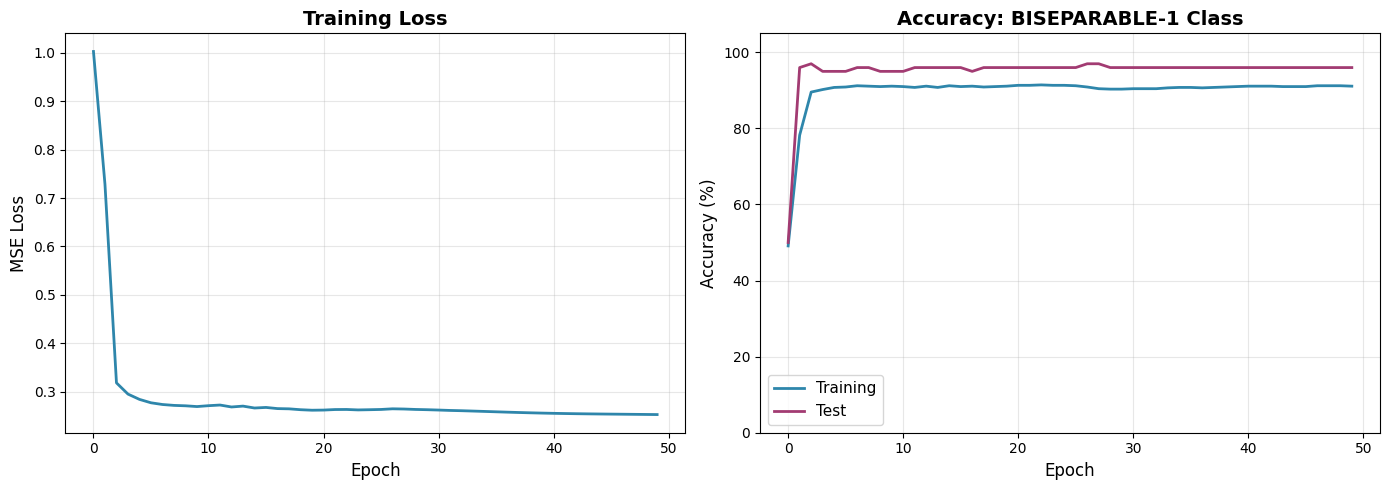

In [5]:
classes = {
    'biseparable-1': [(0, 1)],
    'biseparable-2': [(1, 2)],
    'biseparable-3': [(0, 2)],
}

qnn = QuantumNeuralNetwork(n_layers=2, hidden_dims=[16, 8, 4, 2])

print(qnn.vqc)
print(qnn)
metrics = qnn.train_for_class(
    target_class='biseparable-1',
    entanglement_classes=classes,
    n_train=900,
    n_test=100,
    use_LC=False,  # LC orbit classification
    epochs=50,
    learning_rate=0.01
)

In [6]:
# classes = {
#     'biseparable-1': [(0, 1)],
#     'biseparable-2': [(1, 2)],
#     # 'biseparable-3': [(0, 2)],
# }

# qnn = QuantumNeuralNetwork(n_layers=2, hidden_dims=[16, 8, 4, 2])

# print(qnn.vqc)
# print(qnn)
# metrics = qnn.train_for_class(
#     target_class='biseparable-1',
#     entanglement_classes=classes,
#     n_train=900,
#     n_test=100,
#     use_LC=False,  # LC orbit classification
#     epochs=50,
#     learning_rate=0.01
# )